05_shap_analysis.ipynb
+ SHAP
+ açıklanabilirlik
+ risk faktörleri

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(project_root)

c:\Users\ASUS\creditguard-ai


In [2]:
import numpy as np
import pyarrow

print(np.__version__)
print(pyarrow.__version__)

1.26.4
16.1.0


In [3]:
from src.preprocessing.prepare_dataset import (
    prepare_dataset
)

df = prepare_dataset(
    "../data/processed/train_feature_store.parquet"
)

X = df.drop(
    columns=["TARGET"]
)

print(X.shape)

(307511, 178)


In [ ]:
import joblib
import shap

model = joblib.load(
    #"../artifacts/models/lgbm_tuned.pkl"
    "../artifacts/models/lgbm_optuna_cv.pkl"
)

model

,num_leaves,64
,max_depth,8
,learning_rate,0.03
,n_estimators,1000
,min_child_samples,50
,subsample,0.8
,colsample_bytree,0.8
,reg_alpha,0.1
,reg_lambda,1.0
,random_state,42
,n_jobs,-1


In [5]:
explainer = shap.TreeExplainer(
    model
)

shap_values = explainer.shap_values(
    X.sample(
        5000,
        random_state=42
    )
)

c:\Users\ASUS\creditguard-ai\venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [6]:
sample_X = X.sample(
    5000,
    random_state=42
)

shap_values = explainer.shap_values(
    sample_X
)

c:\Users\ASUS\creditguard-ai\venv\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


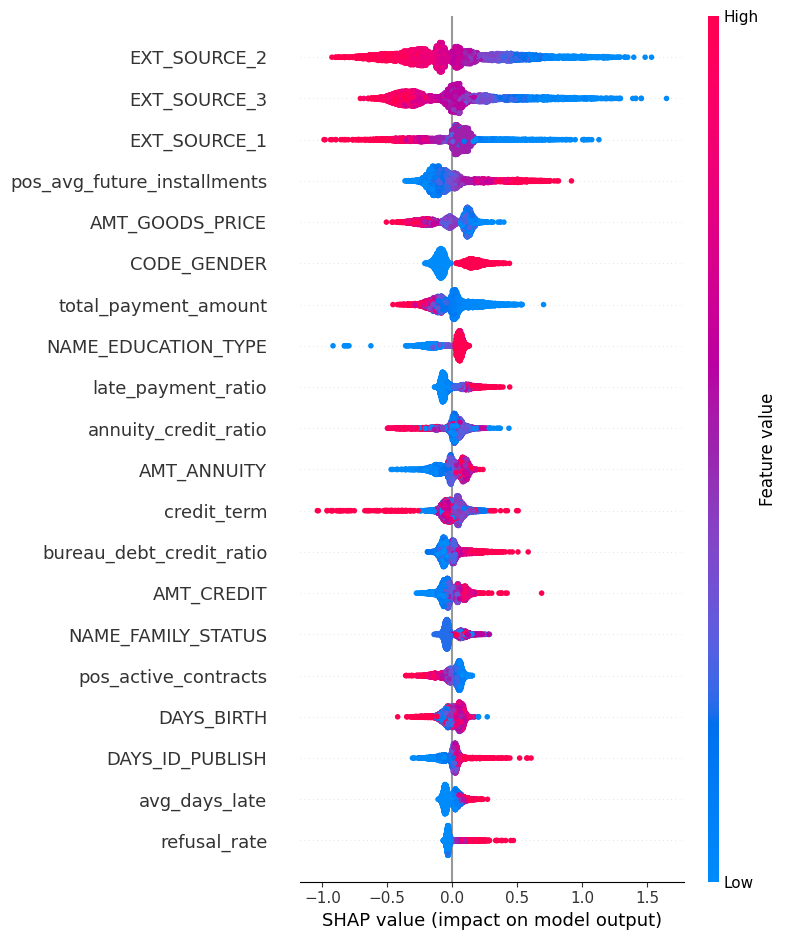

In [7]:
shap.summary_plot(
    shap_values,
    sample_X
)

### Üretilen Feature'lar SHAP Top 20'

| Feature                     | Kaynak                |
| --------------------------- | --------------------- |
| pos_avg_future_installments | POS Cash              |
| total_payment_amount        | Installments          |
| late_payment_ratio          | Installments          |
| avg_days_late               | Installments          |
| bureau_debt_credit_ratio    | Bureau                |
| credit_term                 | Application FE        |
| refusal_rate                | Previous Applications |
| cc_utilization_ratio        | Credit Card           |
| annuity_credit_ratio        | Application FE        |
